# Customer Churn Prediction — Beginner Walkthrough

## What is this project?

A telecom company wants to predict **which customers may leave the company**.

That behaviour is called **churn**.

Our job is to use historical customer data to teach a machine-learning model patterns associated with churn and then use that model on new customers.

### Assignment workflow

**Business Problem → Data → Cleaning → EDA → Feature Engineering → Model → Evaluation → Interpretation → Save Model → API**

We will follow this exact order.

## Step 1 — Import libraries

Think of libraries as ready-made tools.

- `pandas` → works with tables/data
- `numpy` → numerical calculations
- `matplotlib` → charts
- `sklearn` → machine learning
- `joblib` → saves the trained model

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import joblib

# Make the src folder importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from feature_engineering import FeatureEngineer

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2 — Load the dataset

A dataset is simply a table of historical examples.

Each row represents one customer.

Each column represents information about that customer.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "TelcoCustomerChurn.csv"

df = pd.read_csv(DATA_PATH)

print("Rows and columns:", df.shape)
display(df.head())

Rows and columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3 — Understand the structure

We check:
1. Column names
2. Data types
3. Missing values
4. Duplicate rows
5. Numerical vs categorical columns

This is called **data understanding**.

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Missing values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Duplicate rows: 0


### Important observation: `TotalCharges`

The CSV stores `TotalCharges` as text (`object`) even though it represents money.

We convert it to a numeric column. Values that cannot be converted become `NaN` (missing values), which the pipeline will later impute safely.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges after numeric conversion:",
      df["TotalCharges"].isna().sum())

display(df.loc[df["TotalCharges"].isna(),
               ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Missing TotalCharges after numeric conversion: 11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


## Step 4 — Identify the target

The assignment tells us that the target variable is `Churn`.

- `Yes` = churn
- `No` = did not churn

We convert this into:
- `1` = Yes
- `0` = No

Why? Machine-learning algorithms work with numbers.

In [5]:
print(df["Churn"].value_counts())
print("\nPercentage:")
display((df["Churn"].value_counts(normalize=True) * 100).round(2))

y = df["Churn"].map({"No": 0, "Yes": 1})

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

# Step 5 — Exploratory Data Analysis (EDA)

EDA means **looking at the data before modelling**.

We want to understand questions such as:
- How many customers churn?
- Does contract type relate to churn?
- Does internet service relate to churn?
- Do churned customers have different tenure or charges?
- Which customer characteristics look important?

The assignment requires at least 5 meaningful visualizations.

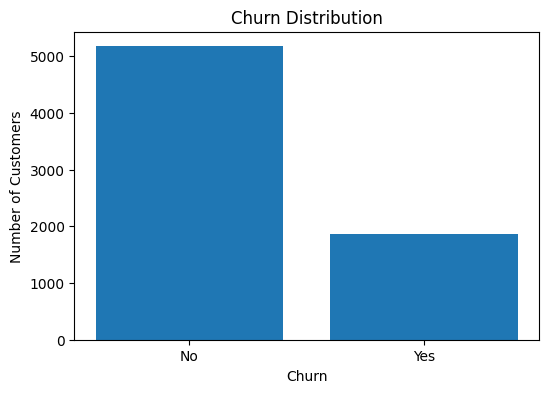

Business insight: churn is the minority class, so accuracy alone can be misleading.


In [6]:
# Visualization 1 — Churn distribution
counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

print("Business insight: churn is the minority class, so accuracy alone can be misleading.")

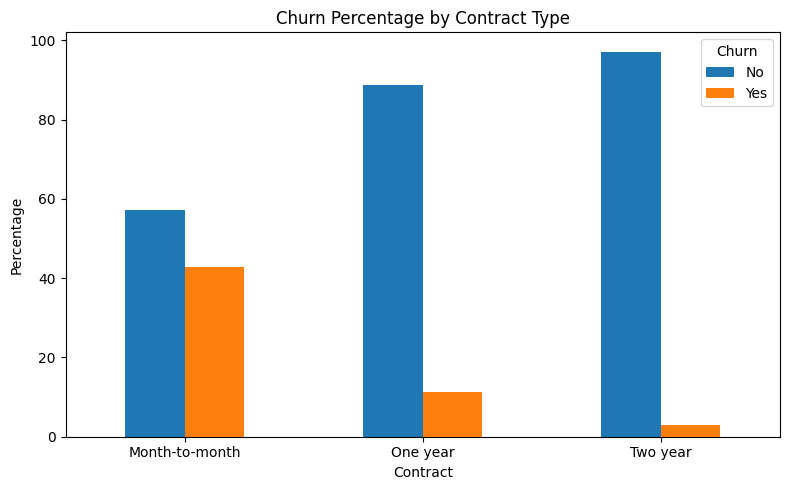

Business insight: month-to-month customers show a substantially higher churn rate than customers on longer contracts.


In [7]:
# Visualization 2 — Churn by Contract
contract_churn = pd.crosstab(
    df["Contract"], df["Churn"], normalize="index"
) * 100

contract_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

print("Business insight: month-to-month customers show a substantially higher churn rate than customers on longer contracts.")

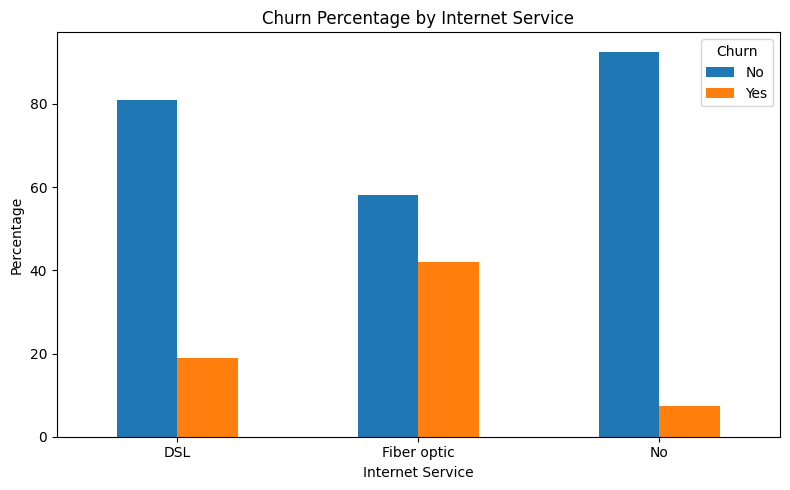

Business insight: the churn rate differs materially by internet service type.


In [8]:
# Visualization 3 — Churn by Internet Service
internet_churn = pd.crosstab(
    df["InternetService"], df["Churn"], normalize="index"
) * 100

internet_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Percentage by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

print("Business insight: the churn rate differs materially by internet service type.")

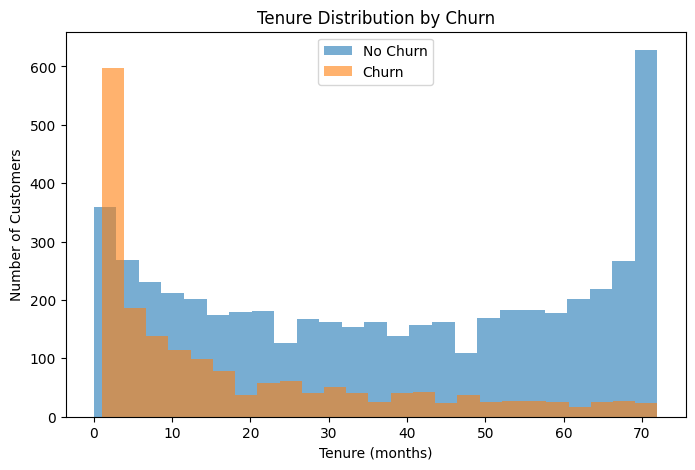

Business insight: churned customers tend to have shorter tenure.


In [9]:
# Visualization 4 — Tenure distribution by churn
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["Churn"] == "No", "tenure"], bins=25, alpha=0.6, label="No Churn")
plt.hist(df.loc[df["Churn"] == "Yes", "tenure"], bins=25, alpha=0.6, label="Churn")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

print("Business insight: churned customers tend to have shorter tenure.")

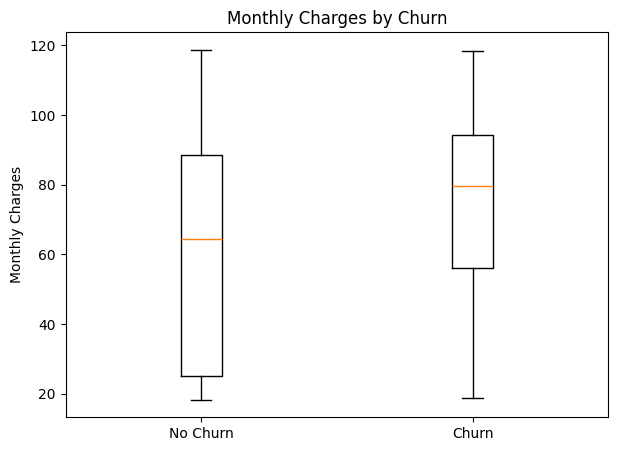

Business insight: churned customers have higher typical monthly charges in this dataset.


In [10]:
# Visualization 5 — Monthly charges by churn
groups = [
    df.loc[df["Churn"] == "No", "MonthlyCharges"],
    df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
]

plt.figure(figsize=(7, 5))
plt.boxplot(groups, tick_labels=["No Churn", "Churn"])
plt.title("Monthly Charges by Churn")
plt.ylabel("Monthly Charges")
plt.show()

print("Business insight: churned customers have higher typical monthly charges in this dataset.")

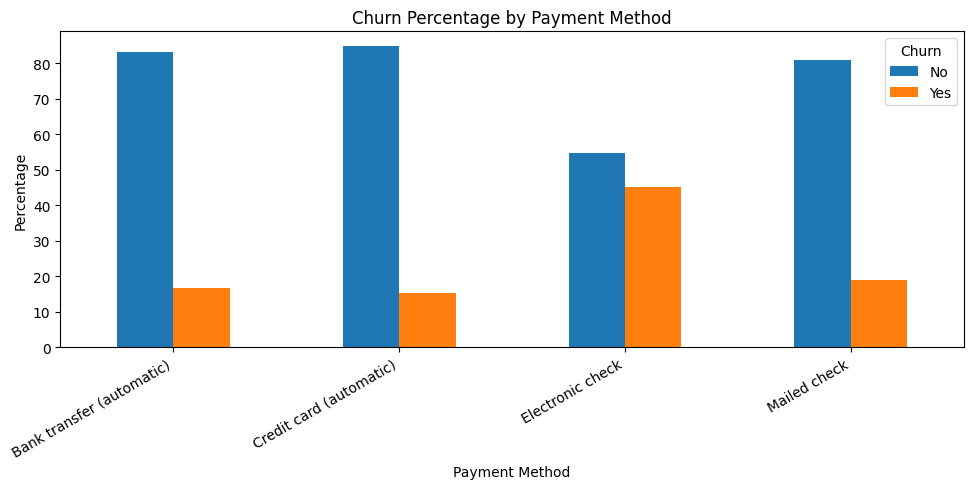

Business insight: churn rates vary across payment methods, with electronic check showing a higher churn rate in this dataset.


In [11]:
# Extra visualization — Payment method
payment_churn = pd.crosstab(
    df["PaymentMethod"], df["Churn"], normalize="index"
) * 100

payment_churn.plot(kind="bar", figsize=(10, 5))
plt.title("Churn Percentage by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

print("Business insight: churn rates vary across payment methods, with electronic check showing a higher churn rate in this dataset.")

## Numerical summary

This helps us connect the charts to actual numbers.

In [12]:
display(
    df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]]
      .mean()
      .round(2)
)

display(
    pd.crosstab(df["Contract"], df["Churn"], normalize="index")
      .round(3)
)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


# Step 6 — Feature Engineering

A **feature** is an input used by the model.

Feature engineering means creating useful new inputs from existing columns.

The assignment requires at least 2 meaningful features.

### Feature 1 — `AvgMonthlySpend`

Formula:

`TotalCharges / tenure`

This gives an approximate average monthly spend across the customer's tenure.

For a zero-tenure customer, we use `MonthlyCharges` instead of dividing by zero.

### Feature 2 — `TotalServices`

We count how many service columns contain `Yes`.

This gives a simple measure of how many services the customer uses.

We also create `TenureGroup` for easier interpretation.

In [13]:
X = df.drop(columns=["Churn"])

feature_engineer = FeatureEngineer()
X_engineered = feature_engineer.transform(X)

display(X_engineered[[
    "tenure", "MonthlyCharges", "TotalCharges",
    "AvgMonthlySpend", "TotalServices", "TenureGroup"
]].head())

print("New features created successfully.")

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,TotalServices,TenureGroup
0,1,29.85,29.85,29.850000,1,0-6
1,34,56.95,1889.50,55.573529,3,25-48
2,2,53.85,108.15,54.075000,3,0-6
3,45,42.30,1840.75,40.905556,3,25-48
4,2,70.70,151.65,75.825000,1,0-6


New features created successfully.


# Step 7 — Train/Test Split

We must not train and test on the same customers.

The assignment requires:
- 70% training
- 30% testing
- `random_state=42`

`stratify=y` keeps the churn/non-churn proportion similar in both sets.

The test set is treated as **unseen data**.

In [14]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 4930
Testing rows: 2113


# Step 8 — Preprocessing

The model cannot directly understand text such as `Month-to-month`.

We therefore use:

### Numerical columns
Missing values → median

### Categorical columns
Missing values → most frequent category  
Text categories → One-Hot Encoding

### Why a Pipeline?

The pipeline guarantees that the same steps are applied during:
- training
- testing
- API prediction on new customers

This helps prevent inconsistent preprocessing and data leakage.

In [15]:
# Determine columns after feature engineering
temp = FeatureEngineer().transform(X_train)

numeric_features = [
    c for c in temp.columns
    if pd.api.types.is_numeric_dtype(temp[c])
]

categorical_features = [
    c for c in temp.columns
    if c not in numeric_features
]

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

def build_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


# Step 9 — Decision Tree

A Decision Tree makes decisions using rules such as:

> Is the contract month-to-month?

> Is tenure low?

> Is the customer using fiber optic internet?

The tree keeps splitting the data into smaller groups.

We will experiment with multiple configurations, as required by the assignment.

In [16]:
configs = {
    "Model A - controlled tree": {
        "max_depth": 5,
        "min_samples_split": 20,
        "class_weight": None
    },
    "Model B - deeper balanced tree": {
        "max_depth": 8,
        "min_samples_leaf": 10,
        "class_weight": "balanced"
    },
    "Model C - balanced final tree": {
        "max_depth": 6,
        "min_samples_leaf": 5,
        "class_weight": "balanced"
    }
}

results = []
trained_models = {}

for name, params in configs.items():
    pipeline = Pipeline([
        ("features", FeatureEngineer()),
        ("preprocessor", build_preprocessor()),
        ("classifier", DecisionTreeClassifier(
            random_state=42, **params
        ))
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1
2,Model C - balanced final tree,0.7425,0.5102,0.7594,0.6103
0,Model A - controlled tree,0.7937,0.6138,0.6007,0.6072
1,Model B - deeper balanced tree,0.7047,0.4657,0.7629,0.5784


## How to read these metrics

### Accuracy
Out of all predictions, how many were correct?

### Precision
Of the customers predicted to churn, how many actually churned?

### Recall
Of the customers who actually churned, how many did we find?

### F1 Score
A combined measure of precision and recall.

For this business use case, **recall deserves particular attention**. If a real churner is missed, the retention team never gets the chance to intervene. A false positive costs an outreach effort, while a false negative may mean losing a customer.

This does not mean precision is unimportant; it means the business should understand the trade-off.

# Step 10 — Select the final model

Model C is used for the final submission:

- `max_depth=6`
- `min_samples_leaf=5`
- `class_weight="balanced"`
- `random_state=42`

Why?

It provides a useful balance of recall and F1 and gives additional attention to the minority churn class.

This is a business/model trade-off, not simply a search for the highest accuracy.

In [17]:
final_model = trained_models["Model C - balanced final tree"]

final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, final_predictions), 4))
print("Precision:", round(precision_score(y_test, final_predictions), 4))
print("Recall   :", round(recall_score(y_test, final_predictions), 4))
print("F1 Score :", round(f1_score(y_test, final_predictions), 4))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, final_predictions)
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test, final_predictions,
    target_names=["No Churn", "Churn"]
))

Accuracy : 0.7425
Precision: 0.5102
Recall   : 0.7594
F1 Score : 0.6103

Confusion Matrix:
[[1143  409]
 [ 135  426]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1552
       Churn       0.51      0.76      0.61       561

    accuracy                           0.74      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.79      0.74      0.76      2113



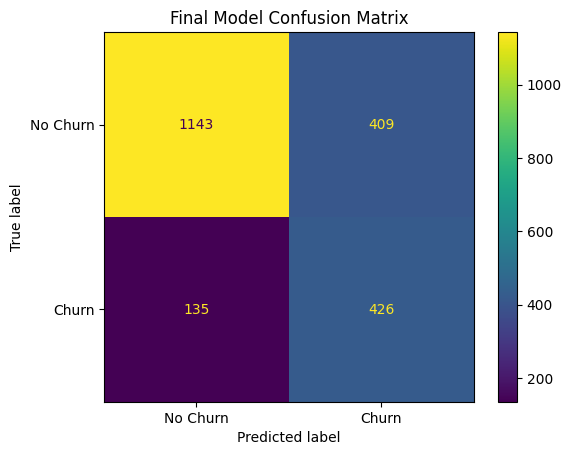

Business meaning:
True Negative = correctly identified non-churn customer
False Positive = contacted someone who did not churn
False Negative = missed a customer who actually churned
True Positive = correctly identified a churner


In [18]:
# Visualization 6 — Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title("Final Model Confusion Matrix")
plt.show()

print("Business meaning:")
print("True Negative = correctly identified non-churn customer")
print("False Positive = contacted someone who did not churn")
print("False Negative = missed a customer who actually churned")
print("True Positive = correctly identified a churner")

# Step 11 — Model Interpretation

Decision Trees are relatively easy to interpret.

We can inspect **feature importance**.

Feature importance tells us which transformed input features contributed most to the tree's decisions.

Important: feature importance shows association with the model's predictions; it does **not** prove that a feature causes churn.

,Feature,Importance
38,cat__Contract_Month-to-month,0.552896
1,num__tenure,0.108876
18,cat__InternetService_Fiber optic,0.092077
2,num__MonthlyCharges,0.051842
3,num__TotalCharges,0.032439
4,num__AvgMonthlySpend,0.026681
29,cat__TechSupport_No,0.023809
20,cat__OnlineSecurity_No,0.020390
45,cat__PaymentMethod_Electronic check,0.019728
36,cat__StreamingMovies_No internet service,0.014974


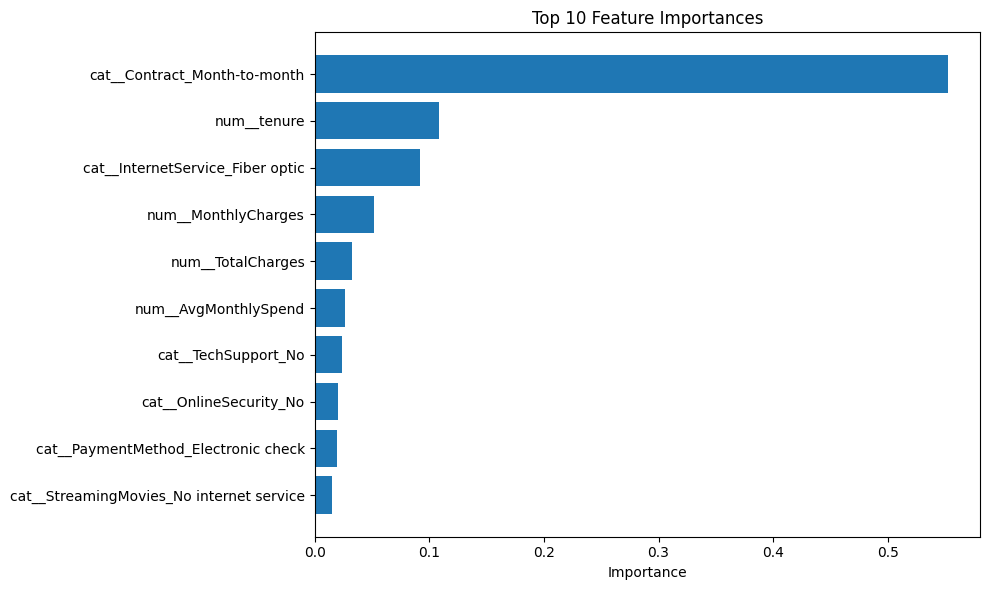

In [19]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = final_model.named_steps[
    "classifier"
].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
top = importance_df.head(10).sort_values("Importance")
plt.barh(top["Feature"], top["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Key interpretation from this dataset

The model places substantial importance on:

1. Contract type, especially month-to-month
2. Tenure
3. Internet service type, particularly fiber optic
4. Monthly charges
5. Average monthly spend
6. Support/security-related service indicators
7. Payment method

These are model signals, not causal conclusions.

The business can use them as areas to investigate when designing retention strategies.

# Step 12 — Visualize the Decision Tree

The complete tree can become large, so we display only the first few levels.

This lets us see how the model creates rule-based decisions.

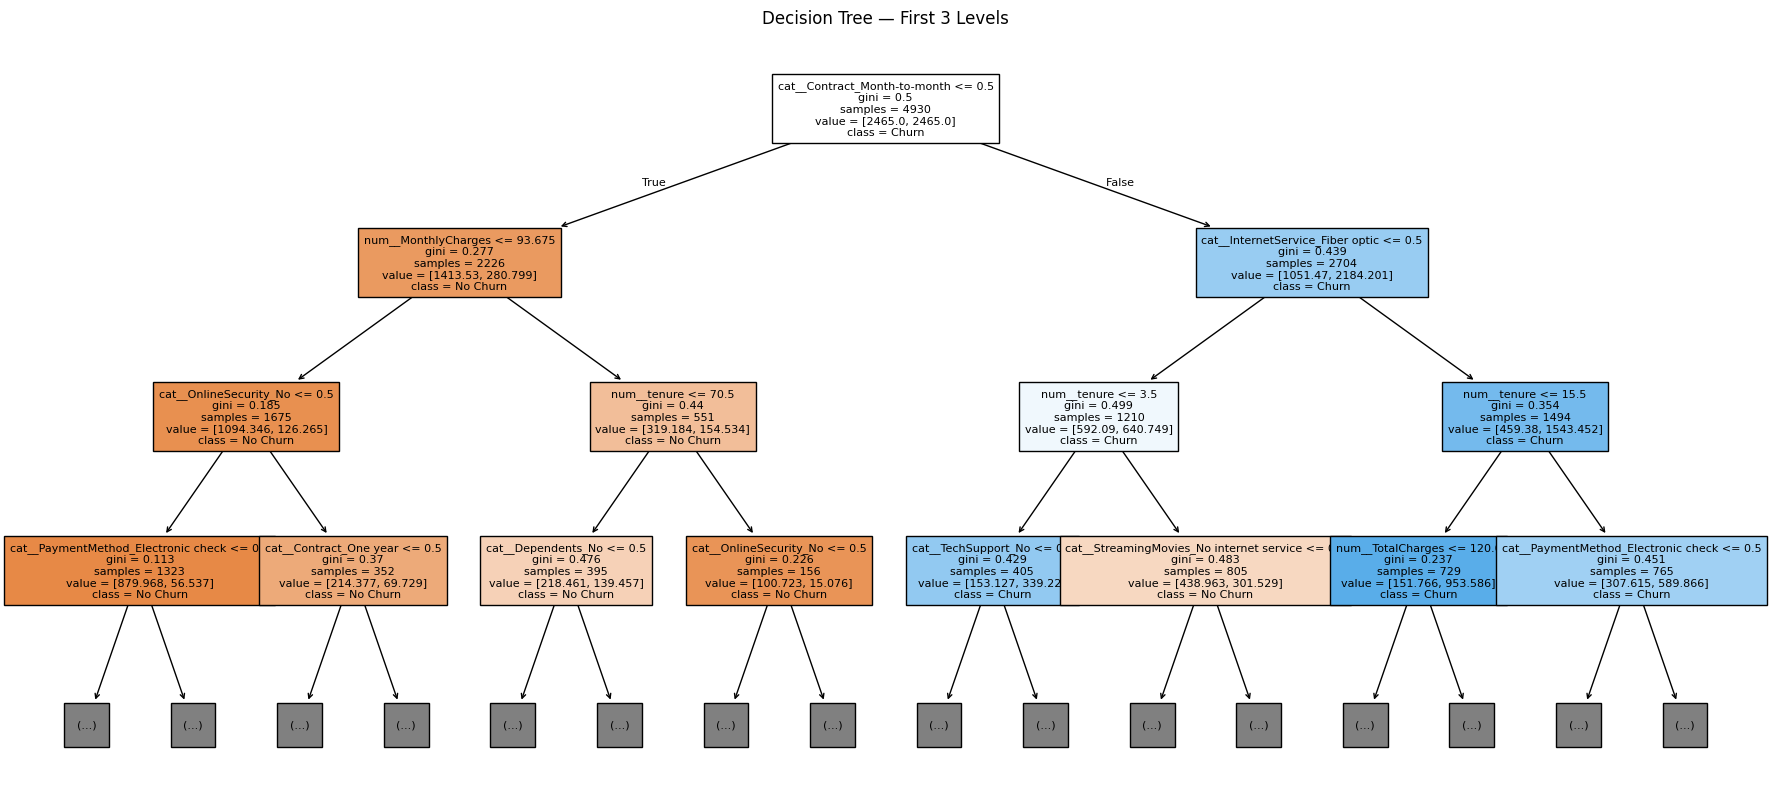

In [20]:
pre = final_model.named_steps["preprocessor"]
tree = final_model.named_steps["classifier"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree,
    feature_names=pre.get_feature_names_out(),
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree — First 3 Levels")
plt.show()

# Step 13 — Save the model

This is very important.

We do **not** save only the Decision Tree.

We save the entire pipeline:

**Feature Engineering → Imputation → Encoding → Decision Tree**

That way the API can accept raw customer JSON and perform exactly the same transformations.

In [21]:
MODEL_PATH = PROJECT_ROOT / "model" / "churn_model.pkl"

joblib.dump(final_model, MODEL_PATH)

print("Saved model to:", MODEL_PATH)

Saved model to: C:\Users\arunbisht\OneDrive - Nagarro\NAGP Assignment\Arun_3145347_DS\model\churn_model.pkl


# Step 14 — Test the saved model on one new customer

This simulates what the API will do.

The customer data is ordinary raw input. We do not manually encode anything.

In [22]:
sample_customer = {
    "customerID": "DEMO-0001",
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.70,
    "TotalCharges": 151.15
}

new_customer = pd.DataFrame([sample_customer])

prediction = final_model.predict(new_customer)[0]
probability = final_model.predict_proba(new_customer)[0, 1]

print("Prediction:", "Yes" if prediction == 1 else "No")
print("Churn probability:", round(float(probability), 4))

Prediction: Yes
Churn probability: 0.7997


# Step 15 — Final business conclusion

The project demonstrates an end-to-end churn prediction workflow.

### What we learned

- The dataset contains 7,043 customer records.
- Churn is the minority class, so precision/recall/F1 are important in addition to accuracy.
- `TotalCharges` needs numeric conversion.
- The model uses feature engineering to create additional customer-level signals.
- A Decision Tree can provide both predictions and interpretable feature importance.
- The final balanced tree is designed to identify more potential churners.
- The saved pipeline makes the same preprocessing reusable for API requests.

### Business perspective

The retention team can use the model's churn probability to identify customers for proactive engagement. The exact operational threshold should be decided using outreach capacity, retention cost, and the value of retaining a customer.